<a href="https://colab.research.google.com/github/ayushman-c/kaggle-notebooks/blob/main/Linear_Regression/EnergyConsumption.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/test_energy_data.csv")
print(df.shape)

(100, 7)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        100 non-null    object 
 1   Square Footage       100 non-null    int64  
 2   Number of Occupants  100 non-null    int64  
 3   Appliances Used      100 non-null    int64  
 4   Average Temperature  100 non-null    float64
 5   Day of Week          100 non-null    object 
 6   Energy Consumption   100 non-null    float64
dtypes: float64(2), int64(3), object(2)
memory usage: 5.6+ KB


In [8]:
df.head()


,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,24563,15,4,28.52,Weekday,2865.57
1,Commercial,27583,56,23,23.07,Weekend,4283.80
2,Commercial,45313,4,44,33.56,Weekday,5067.83
3,Residential,41625,84,17,27.39,Weekend,4624.30
4,Residential,36720,58,47,17.08,Weekday,4820.59


<Axes: >

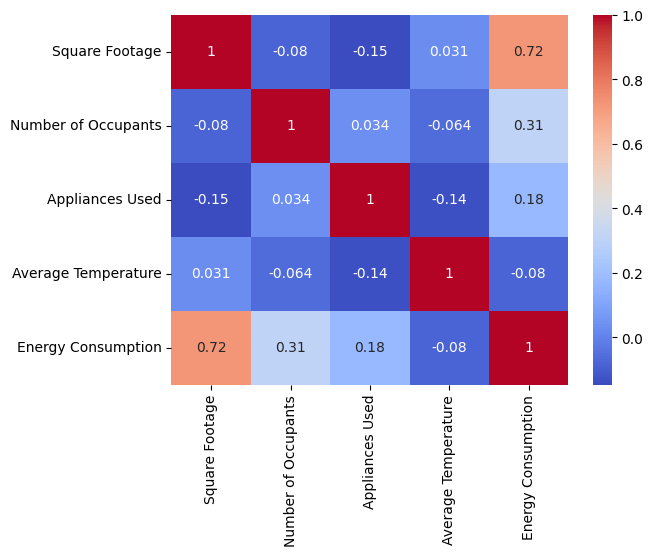

In [9]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")

#we deduce we have a strong corellation of Energy comsumpotion and the Square footage

<Axes: xlabel='Square Footage', ylabel='Energy Consumption'>

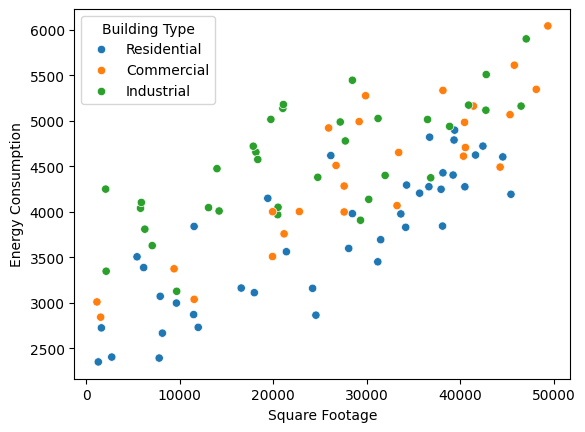

In [14]:
sns.scatterplot(x="Square Footage", y="Energy Consumption", data=df,hue='Building Type')


In [16]:
X = df.iloc[:,1]
Y = df.iloc[:,-1]
print(X.head())
print(Y.head())

0    24563
1    27583
2    45313
3    41625
4    36720
Name: Square Footage, dtype: int64
0    2865.57
1    4283.80
2    5067.83
3    4624.30
4    4820.59
Name: Energy Consumption, dtype: float64


In [18]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.1,random_state=2)

In [20]:
print(X_train.shape)
print(X_test.shape)

(90,)
(10,)


In [22]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train.values.reshape(-1,1),y_train)

LinearRegression()

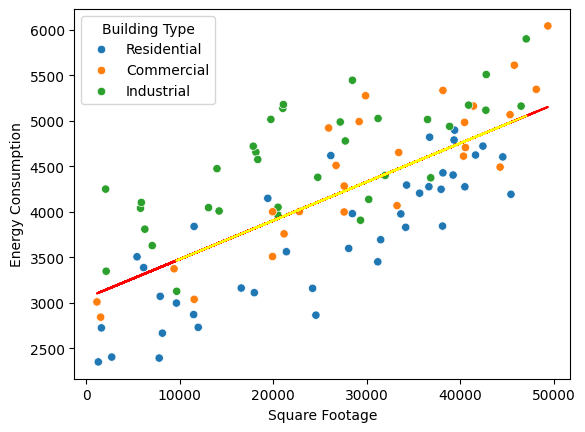

In [26]:
sns.scatterplot(x="Square Footage", y="Energy Consumption", data=df,hue='Building Type')
plt.plot(X_train,lr.predict(X_train.values.reshape(-1,1)),color='red')
plt.plot(X_test,lr.predict(X_test.values.reshape(-1,1)),color='yellow')

In [28]:
print(X_test.head())
print(y_test.head())

83    47042
30    27708
56     9655
24    42767
16    27165
Name: Square Footage, dtype: int64
83    5900.32
30    4779.08
56    2998.47
24    5508.64
16    4987.52
Name: Energy Consumption, dtype: float64


In [32]:
lr.predict(X_test.iloc[3].reshape(-1,1))

array([4872.36195583])

In [33]:
def error_percent(diff,org):
  error = (diff/org)*100
  return error

total_error_sum = 0 # Initialize the sum variable

for i in range(len(X_test)):
  predicted_value = lr.predict(X_test.iloc[i].reshape(-1,1))
  diff = abs(predicted_value - y_test.iloc[i])
  total_error_sum = total_error_sum + error_percent(diff,y_test.iloc[i]) # Use the new variable name

error_percentage = total_error_sum/len(X_test) # Renamed to avoid conflict
print(error_percentage)


[11.75737505]
